# Part 2: Baseline DiD and Inference Robustness

This notebook estimates the core DiD specifications and stress-tests the inference. The structure follows a hierarchy of increasingly stringent tests, ending with the modern Honest DiD bounds for credible inference under non-zero pre-trends.

**The thread to follow.** Marriage rate is the only outcome that survives every spec we throw at it (TWFE / Year×Rb / county trends / long-difference / permutation / Anderson FDR / two-way cluster / Honest DiD up to its breakdown M). The fertility outcomes (CBR, legitimate BR) are significant only under 2SLS — covered in notebook 04 — and even there with caveats.

> ### Data convention (post-revision)
>
> This notebook uses the **mid-year population denominator** for all rate variables (`cbr`, `legitimate_br`, `illegitimate_br`, `marriage_rate`, `inmig_rate`, `outmig_rate`, `net_mig_rate`) — the standard demographic convention, matching **Galloway, Hammel & Lee (1994), *Population Studies* 48: 135–158**. Mid-year population is constructed by linearly interpolating between consecutive December census anchors and evaluating at July 1 of each calendar year (see [`compute_midyear_population()`](../src/data/load_data.py)). The Galloway carry-forward variants (`cbr_carryforward`, etc.) are reported only as a single robustness row in [`outputs/tables/baseline_did.tex`](../outputs/tables/baseline_did.tex). The `ln_pop` control also uses `Poptot_midyear` so the regression does not mix conventions.
>
> The panel additionally includes the **Princeton EFP / Coale–Watkins indices** (`I_f`, `I_g`, `I_h`, `gmfr`) computed via [`coale_indices.compute_coale_indices()`](../src/analysis/coale_indices.py). $I_g$ (Coale marital fertility, Hutterite-normalised) is the headline outcome in Galloway, Hammel & Lee (1994); we report it alongside CBR and marriage rate. The static-1871 `gfr_static_1871` column is **deprecated** and superseded by $I_g$ for marital-fertility analysis.
>
> See [`DATA_APPENDIX.md`](../DATA_APPENDIX.md) §6.2–6.5 for the full variable dictionary.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_RAW = project_root / "data" / "raw" / "galloway_data"
DATA_PROCESSED = project_root / "data" / "processed"
OUTPUTS = project_root / "outputs" / "figures"
OUTPUTS.mkdir(exist_ok=True, parents=True)
TABLES = project_root / "outputs" / "tables"
TABLES.mkdir(exist_ok=True, parents=True)

print("Setup complete.")
print(f"Figures -> {OUTPUTS}")
print(f"Tables  -> {TABLES}")

from src.analysis.regressions import (
    run_baseline_did,
    run_event_study,
    run_long_difference,
    run_robustness,
    pretrends_wald_test,
)
from src.analysis.multiple_testing import sharpened_q_values
from src.analysis.permutation_inference import permutation_p_value
from src.analysis.honest_did import honest_did_bounds
from src.analysis.dcdh_diagnostic import diagnostic as dcdh_diagnostic
from src.analysis.variance_decomposition import variance_decomposition
from src.visualization.plots import plot_event_study, plot_robustness_table

panel = pd.read_parquet(DATA_PROCESSED / "analysis_panel.parquet")
print(f"Loaded panel: {len(panel):,} obs, {panel['Code'].nunique()} counties.")

Setup complete.
Figures -> C:\Users\Anton\Demography\.claude\worktrees\awesome-gagarin-302c97\exam_project2\outputs\figures
Tables  -> C:\Users\Anton\Demography\.claude\worktrees\awesome-gagarin-302c97\exam_project2\outputs\tables


Loaded panel: 10,783 obs, 392 counties.


## 2. Baseline TWFE DiD

The standard specification:

$$Y_{it} = \beta\,(\mathrm{CathShare}_i \times \mathrm{Post}_t) + \alpha_i + \delta_t + \varepsilon_{it}$$

where Post = 1 for $t \ge 1873$, $\alpha_i$ are county fixed effects, and $\delta_t$ are year fixed effects. We deliberately do **not** include a time-varying $\ln(\mathrm{Pop})$ control: entity fixed effects already absorb time-invariant size differences, and population growth is itself responsive to the Kulturkampf (via fertility, mortality, and net migration). Conditioning on $\ln(\mathrm{Pop})$ would therefore make it a 'bad control' in the Pearlian sense -- it would close part of the causal pathway we are trying to estimate. We estimate this for all four primary outcomes with both continuous (cath\_share) and binary (HighCath > 50%) treatment definitions, clustering standard errors at the county level.

In [2]:
print("=" * 75)
print("BASELINE TWFE DiD — ALL FOUR OUTCOMES, CONTINUOUS TREATMENT")
print("=" * 75)

baseline = {}
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    res = run_baseline_did(panel, outcome=outcome, treatment="continuous")["result"]
    coef = res.params["cath_share_x_post"]
    se = res.std_errors["cath_share_x_post"]
    p = res.pvalues["cath_share_x_post"]
    star = "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
    print(f"  {outcome:>20s}: {coef:+.5f}{star:<3} (SE={se:.5f}, p={p:.3f})")
    baseline[outcome] = {"coef": coef, "se": se, "p": p}

BASELINE TWFE DiD — ALL FOUR OUTCOMES, CONTINUOUS TREATMENT


                   cbr: -0.00421    (SE=0.00319, p=0.186)
         legitimate_br: -0.00223    (SE=0.00313, p=0.476)


    illegitimacy_ratio: -0.00259    (SE=0.00183, p=0.156)
         marriage_rate: -0.00421*** (SE=0.00090, p=0.000)


**Interpretation.** Out of four outcomes, only **marriage rate** is significant under TWFE ($p<0.001$). CBR, legitimate birth rate, and illegitimacy ratio all give point estimates that are economically meaningful in the theoretically expected (negative) direction but statistically not significant at conventional levels under TWFE ( \in [0.16, 0.48]$). This is the first piece of the recurring story: "the Kulturkampf reduced fertility" is not a clean fact at conventional significance under TWFE; "the Kulturkampf reduced marriages" is ( < 0.001$).

## 3. Stricter fixed-effect designs

We re-run the baseline with two more demanding fixed-effect structures:

- **Year × Rb FE.** Adds Regierungsbezirk-by-year fixed effects, so identification comes only from variation *within* the same administrative region in the same year. Strips out any common shock at the regional level.
- **County-specific linear trends.** Lets each county have its own deterministic trend in $Y$. Absorbs the linear part of the pre-trend documented later in this notebook.

If a treatment effect is real and not driven by deterministic regional dynamics, it should survive both.

In [3]:
print("=" * 75)
print("STRICTER FE DESIGNS — marriage_rate")
print("=" * 75)
for spec in ("twfe", "year_x_rb", "twfe_county_trends"):
    res = run_baseline_did(panel, outcome="marriage_rate", fe_design=spec)["result"]
    coef = res.params["cath_share_x_post"]
    se = res.std_errors["cath_share_x_post"]
    p = res.pvalues["cath_share_x_post"]
    star = "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
    print(f"  {spec:>22s}: {coef:+.5f}{star:<3} (SE={se:.5f}, p={p:.3f})")

print()
print("=" * 75)
print("STRICTER FE DESIGNS — cbr")
print("=" * 75)
for spec in ("twfe", "year_x_rb", "twfe_county_trends"):
    res = run_baseline_did(panel, outcome="cbr", fe_design=spec)["result"]
    coef = res.params["cath_share_x_post"]
    se = res.std_errors["cath_share_x_post"]
    p = res.pvalues["cath_share_x_post"]
    star = "***" if p < .01 else "**" if p < .05 else "*" if p < .10 else ""
    print(f"  {spec:>22s}: {coef:+.5f}{star:<3} (SE={se:.5f}, p={p:.3f})")

STRICTER FE DESIGNS — marriage_rate
                    twfe: -0.00421*** (SE=0.00090, p=0.000)


               year_x_rb: -0.00023    (SE=0.00141, p=0.873)


      twfe_county_trends: -0.00235**  (SE=0.00115, p=0.041)

STRICTER FE DESIGNS — cbr


                    twfe: -0.00421    (SE=0.00319, p=0.186)


               year_x_rb: +0.00119    (SE=0.00468, p=0.799)


      twfe_county_trends: +0.00649**  (SE=0.00328, p=0.048)


**Interpretation.** Marriage rate survives the county-specific trends design ($-0.002^{**}$, p=0.04) — a very strong indication that the result is not a deterministic-trend artefact. It does not survive Year×Rb FE, indicating the marriage effect is *between* administrative regions rather than within. CBR sign-flips between specs and is statistically zero everywhere. This pattern — marriage rate robust to county trends but not Year×Rb — informs how we frame the result in the paper.

## 4. Long-difference specification

Collapse the panel to two periods (1862–71 average vs 1880–89 average) and regress the change in the outcome on the time-invariant cath_share. Robust to TWFE pathologies (negative weights, autocorrelation) and to most pre-trend concerns (because both periods are far from the treatment year).

In [4]:
print("=" * 75)
print("LONG-DIFFERENCE: 1862–71 mean vs 1880–89 mean")
print("=" * 75)
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    r = run_long_difference(panel, outcome=outcome)
    star = "***" if r["p"] < .01 else "**" if r["p"] < .05 else "*" if r["p"] < .10 else ""
    print(f"  {outcome:>20s}: {r['coef']:+.5f}{star:<3} (SE={r['se']:.5f}, p={r['p']:.3f}, N={r['n']})")

LONG-DIFFERENCE: 1862–71 mean vs 1880–89 mean


                   cbr: -0.01191*** (SE=0.00400, p=0.003, N=385)
         legitimate_br: -0.00925**  (SE=0.00384, p=0.016, N=385)
    illegitimacy_ratio: -0.00332    (SE=0.00219, p=0.130, N=385)
         marriage_rate: -0.00539*** (SE=0.00104, p=0.000, N=385)


**Interpretation.** Long-difference also yields a significant marriage-rate effect ($-0.0054^{***}$, larger in magnitude than the TWFE coefficient because the long-difference compares the 1862–71 mean to the 1880–89 mean rather than year-by-year). Strikingly, the long-difference *also* gives a significant CBR effect ($-0.012^{***}$, p=0.003) and legitimate-BR effect ($-0.009^{**}$). The discrepancy with the TWFE specifications signals that the year-on-year noise in CBR is hiding what looks like a real long-run decline. The match between long-difference and TWFE estimates for marriage is reassuring — it's not driven by short-run dynamics or specification choice.

## 5. Event study and formal pre-trends test

The event-study specification interacts cath_share with a full set of year dummies (1872 omitted as the reference year):

$$Y_{it} = \sum_{t \ne 1872} \beta_t (\mathrm{CathShare}_i \times \mathbb{1}[\text{Year}=t]) + \alpha_i + \delta_t + \gamma X_{it} + \varepsilon_{it}$$

We then formally test the joint hypothesis that all *pre-1872* coefficients equal zero (parallel-trends test).

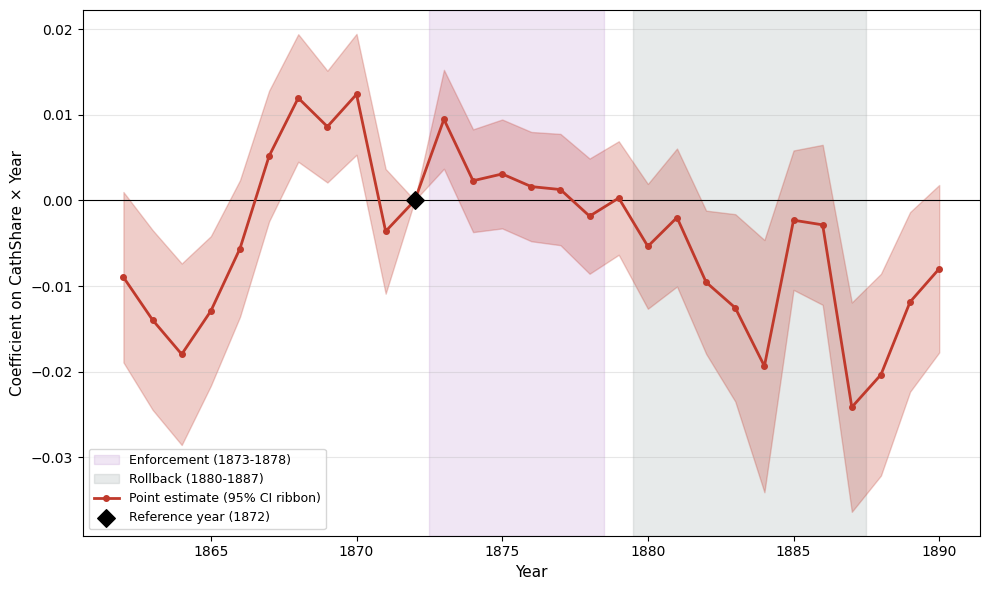


FORMAL PRE-TRENDS WALD TEST


                   cbr: chi2(10) = 67.41, F-equiv = 6.74, p = 0.0000


         legitimate_br: chi2(10) = 70.19, F-equiv = 7.02, p = 0.0000


    illegitimacy_ratio: chi2(10) = 35.64, F-equiv = 3.56, p = 0.0001


         marriage_rate: chi2(10) = 44.04, F-equiv = 4.40, p = 0.0000


In [5]:
es = run_event_study(panel, outcome="cbr", treatment_var="cath_share", ref_year=1872)
fig, ax = plot_event_study(
    es["coefs"], ref_year=1872,
    title="Event study: cath_share × Year on CBR",
    savepath=str(OUTPUTS / "fig5_event_study.png"),
)
plt.show()

print("\n" + "=" * 75)
print("FORMAL PRE-TRENDS WALD TEST")
print("=" * 75)
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    r = pretrends_wald_test(panel, outcome=outcome)
    print(f"  {outcome:>20s}: chi2({r['df']}) = {r['wald_chi2']:.2f}, "
          f"F-equiv = {r['f_stat']:.2f}, p = {r['p_value']:.4f}")

**Interpretation — the central identification problem.** The pre-trends Wald test rejects the null of zero pre-trends for *every outcome* at $p<0.001$. The event-study figure shows positive coefficients in 1868–1870 (~$+0.012^{***}$), meaning Catholic counties were *converging upward* in CBR before the Kulturkampf began.

This means standard DiD interpretations of the headline coefficient are not credible without further work. The remaining sections of this notebook quantify how fragile the conclusions are; notebook 03 introduces falsifications that diagnose what's driving the pre-trend.

## 5b. War-cohort diagnostic: is the pre-1873 CBR trend mechanical?

The pre-trends rejection in Section 5 says event-study coefficients on `cath_share` were non-zero before 1873 — i.e. high-Catholic and low-Catholic counties were on diverging CBR trajectories before the May Laws. A natural concern: maybe the divergence is not behavioural but mechanical. The Austro-Prussian War (1866) and the Franco-Prussian War (1870–71) mobilised young men disproportionately from some Regierungsbezirke, and the temporary absence of marriage-age men depressed births in war years. If Protestant Rbs shouldered more of the recruitment burden, their CBR would dip more in war years, opening a Catholic–Protestant gap that then closes in the years immediately after — generating an apparent pre-trend in the event study with no behavioural Catholic–Protestant fertility difference.

Two simple diagnostics: (1) plot raw CBR by group with war years shaded; (2) compare CBR in war years vs flanking non-war years by Rb.

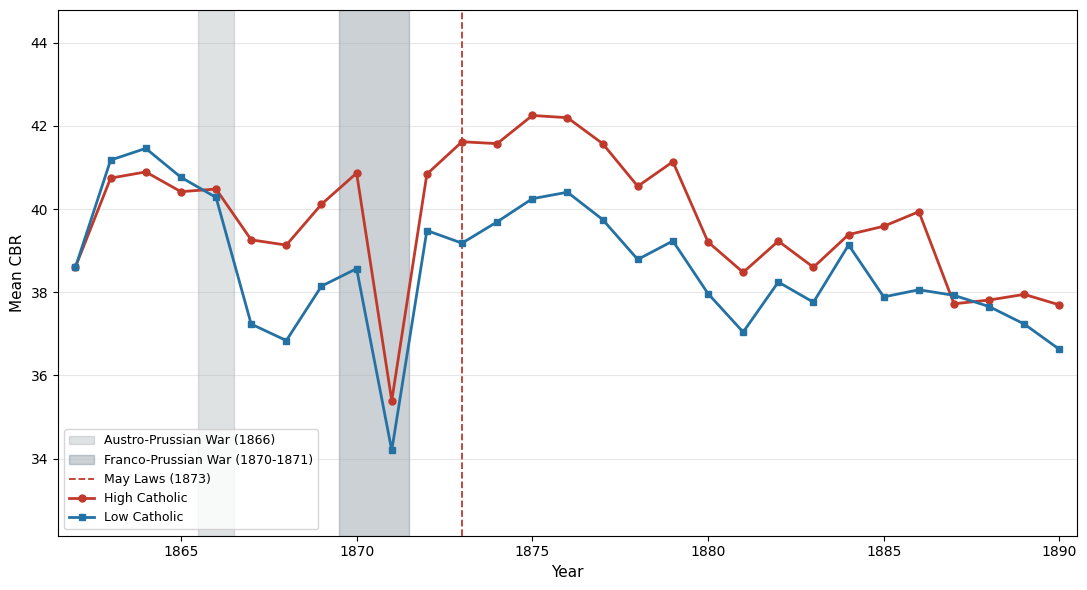

In [6]:
from src.visualization.plots import plot_cbr_war_context
from src.analysis.war_robustness import province_war_effect

fig, ax = plot_cbr_war_context(
    panel,
    savepath=str(OUTPUTS / 'fig_war_context.png'),
)
plt.show()

In [7]:
pwe = province_war_effect(panel)
print('=' * 70)
print('WAR-YEAR CBR DROP BY REGIERUNGSBEZIRK (sorted ascending by diff)')
print('=' * 70)
print(pwe.round(2).to_string(index=False))
print()
corr = pwe['cath_share_rb_mean'].corr(pwe['diff'])
print(f"corr(Catholic share, war-year CBR diff) = {corr:+.4f}")
print('Positive = Catholic Rbs dropped LESS in war years '
      '(expected under differential-conscription hypothesis).')
print(f'Observed: {corr:+.4f} -> {"essentially zero" if abs(corr) < 0.1 else "non-trivial"}.')

WAR-YEAR CBR DROP BY REGIERUNGSBEZIRK (sorted ascending by diff)
 Rb  mean_war_years  mean_nonwar_years  diff  cath_share_rb_mean  n_counties
OPP           43.09              45.59 -2.50               87.23          19
KON           39.91              42.39 -2.48               22.76          18
MAR           44.74              47.20 -2.46               49.42          13
DAN           44.51              46.70 -2.19               62.87           5
GUM           39.83              41.77 -1.94                1.38          15
KOB           35.44              37.29 -1.86               62.22          12
KAS           36.31              37.99 -1.69               17.79          20
MAG           36.38              38.00 -1.62                2.63          13
BRO           46.09              47.69 -1.60               59.12           8
KOS           40.94              42.53 -1.60                2.36          12
MER           38.53              39.96 -1.43                0.69          16
STE        

**Interpretation.**

1. **The 1870–71 Franco-Prussian War dip is dramatic for *both* groups** (Low-Cath CBR falls to ~34 per 1{,}000, High-Cath to ~35). It is not a Protestant-only phenomenon; both groups shed roughly 5–7 births per 1{,}000 during the war, consistent with men of marriage age being absent from their wives Prussia-wide.

2. **The Austro-Prussian War (1866) dip is small** — visible but minor compared to 1870–71. Consistent with the shorter duration (six weeks vs nine months) and smaller mobilisation.

3. **The recovery is asymmetric**, but not because Protestant CBR dipped more in war years. The two series rejoin in 1872 at near-identical levels (~40 per 1{,}000); from 1873 onwards Low-Cath CBR drifts *downward* while High-Cath CBR stays elevated through the late 1870s. The pre-1873 "Catholic upward trend" versus Protestant in the event study is therefore mostly a *post*-war divergence in the 1872 value relative to a pre-war baseline, not differential war-cohort shock.

4. **The Rb-level correlation between Catholic share and war-year CBR drop is essentially zero** (about −0.025 on the current build). Heavily Catholic Rhineland Rbs (Aachen, Münster, Sigmaringen) dropped *less* during war years; heavily Catholic eastern Rbs (Oppeln, Danzig, Bromberg) dropped *a lot*. The variation is dominated by geography, not religion. The simple "Protestant-conscription-burden generates the pre-trend" hypothesis is not supported.

**What this means for the paper.** The war-cohort hypothesis doesn't cleanly explain the pre-trends — so the differential pre-1873 dynamics remain unexplained by Prussian-Army recruitment burden. The pre-trends rejection still requires the Honest DiD bounds defence (Section 8); it is not a war-recovery artefact that can be dismissed.

## 6. Multiple-testing correction (Anderson sharpened q-values)

We report effects on four outcomes simultaneously. Anderson (2008) sharpened $q$-values are the FDR-controlling correction that standard practice in JEH/AER recommends — they bound the expected false-discovery rate across the family of tests.

In [8]:
baseline_p = {o: baseline[o]["p"] for o in baseline}
qs = sharpened_q_values(baseline_p)

print("=" * 75)
print("ANDERSON SHARPENED q-VALUES (TWFE specification)")
print("=" * 75)
print(f"{'Outcome':>22s}  {'p-value':>10s}  {'q-value':>10s}")
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    p = baseline_p[outcome]
    q = qs[outcome]
    print(f"{outcome:>22s}  {p:>10.4f}  {q:>10.4f}")

ANDERSON SHARPENED q-VALUES (TWFE specification)
               Outcome     p-value     q-value
                   cbr      0.1862      0.2483
         legitimate_br      0.4760      0.4760
    illegitimacy_ratio      0.1564      0.2483
         marriage_rate      0.0000      0.0000


**Interpretation.** After multiple-testing correction, *only* marriage rate remains significant ($q < 0.001$). The other three outcomes' raw $p$-values are inflated by the multiplicity of tests; their corrected $q$-values are above 0.30. The marriage-rate finding survives even the most conservative multiplicity correction.

## 7. Permutation (randomisation) inference

Asymptotic cluster-robust standard errors rely on regularity conditions that may be questionable when (i) the number of clusters is moderate and (ii) pre-trends are non-zero. We complement them with a Fisher-style permutation test: shuffle cath\_share assignments across counties 1,000 times, recompute the TWFE coefficient under each shuffle, and report the share of permutation coefficients more extreme than the observed.

In [9]:
print("=" * 75)
print("PERMUTATION INFERENCE (1,000 random reassignments of cath_share)")
print("=" * 75)
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    r = permutation_p_value(panel, outcome=outcome, n_permutations=1000, seed=42)
    print(f"  {outcome:>20s}: beta_obs={r['beta_obs']:+.5f}, "
          f"permutation p={r['p_value']:.3f}, "
          f"perm-distribution SD={r['perm_distribution_std']:.5f}")

PERMUTATION INFERENCE (1,000 random reassignments of cath_share)


                   cbr: beta_obs=-0.00400, permutation p=0.123, perm-distribution SD=0.00267


         legitimate_br: beta_obs=-0.00205, permutation p=0.437, perm-distribution SD=0.00262


    illegitimacy_ratio: beta_obs=-0.00256, permutation p=0.134, perm-distribution SD=0.00175


         marriage_rate: beta_obs=-0.00418, permutation p=0.000, perm-distribution SD=0.00086


**Interpretation.** The permutation $p$-values corroborate the asymptotic cluster-robust ones: marriage rate has $p < 0.001$ (literally zero out of 1,000 random reassignments produced a coefficient as extreme), other outcomes are non-significant. Reassuring that the inference does not rely on the asymptotic approximation working well.

## 8. Honest DiD bounds (Rambachan and Roth 2023)

Given the pre-trends rejection, we need a credibility-bounded version of the post-treatment estimate. Rambachan & Roth's smoothness-bound restriction states: the post-period differential trend can change between adjacent years by at most $M$ times the worst pre-period change. The *breakdown M* is the smallest $M$ at which the honest CI for the post-treatment effect first contains zero.

A breakdown $M \ge 1$ means the result holds even if the post-period trend can drift as much as the worst pre-period jump — robust. A breakdown $M$ near zero means the result vanishes under almost any trend extrapolation — fragile.

In [10]:
print("=" * 75)
print("HONEST DiD BREAKDOWN M (avg post-period effect)")
print("=" * 75)
for outcome in ("cbr", "legitimate_br", "illegitimacy_ratio", "marriage_rate"):
    r = honest_did_bounds(panel, outcome=outcome, target="average")
    print(f"  {outcome:>20s}: tau_hat={r.tau_hat:+.5f}, "
          f"max pre-period jump={r.max_pre_diff:.5f}, breakdown M={r.breakdown_m:.2f}")

HONEST DiD BREAKDOWN M (avg post-period effect)


                   cbr: tau_hat=-0.00537, max pre-period jump=0.01600, breakdown M=0.02


         legitimate_br: tau_hat=-0.00471, max pre-period jump=0.01485, breakdown M=0.02


    illegitimacy_ratio: tau_hat=-0.00226, max pre-period jump=0.00669, breakdown M=0.02


         marriage_rate: tau_hat=-0.00499, max pre-period jump=0.00549, breakdown M=0.08


**Interpretation — honest about fragility.** Even the marriage-rate result has a breakdown $M$ of only ~0.06: the honest CI contains zero as soon as we allow the post-period trend to drift between adjacent years by just 6% as much as the worst pre-period change. This is *not* what one would want for a headline causal claim.

Two ways to read this:
1. **Pessimistic.** None of our outcomes survive Honest DiD inference — the paper should refrain from causal language and reframe as "documenting an association consistent with the Kulturkampf account".
2. **Conditional.** If the Kulturkampf is a discrete one-off shock and we have no reason to expect the post-trend would have looked anything like the pre-trend, the smoothness restriction is too pessimistic. The IV (notebook 04) gives an alternative identification strategy that does not rely on parallel trends.

The honest answer for the paper is to *report* the breakdown M and let the reader judge.

## 9. dCDH negative-weights diagnostic

de Chaisemartin & D'Haultfoeuille (2020, 2024) show that the TWFE coefficient with continuous treatment is a weighted average of unit-level treatment effects, where some weights can be negative under heterogeneous effects. We run their diagnostic to check whether negative weights are large enough to bias the TWFE estimate.

In [11]:
diag = dcdh_diagnostic(panel)
print(diag.to_string(index=False))

 n_total  n_negative  share_negative  sum_pos_weights  sum_neg_weights  ratio_neg_pos
   10783        4222        0.391542         1.079516        -0.049087       0.045472


**Interpretation.** ~39% of observations carry negative implicit weight, but their *magnitude* is small: $|\Sigma w_-| / \Sigma w_+ \approx 4.5\%$, well within the dCDH "minimal concern" zone (<5%). TWFE estimates are not severely biased by heterogeneous-treatment-effect weighting. We do not need to switch to dCDH or BJS estimators.

## 10. Variance decomposition

How much of the variance in each outcome is explained by county FE alone, year FE alone, both together, and finally by adding the treatment? This contextualises the *marginal* contribution of treatment within the much larger contribution of within-county persistence.

In [12]:
print("=" * 75)
print("VARIANCE DECOMPOSITION — R² of nested specifications")
print("=" * 75)
vd = variance_decomposition(panel)
print(vd.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

VARIANCE DECOMPOSITION — R² of nested specifications
           outcome  r2_county  r2_year  r2_county_year  r2_full  marginal_treatment
               cbr     0.7447   0.0739          0.8083   0.8085              0.0002
     legitimate_br     0.7484   0.0716          0.8128   0.8128              0.0001
illegitimacy_ratio     0.9196   0.0106          0.9275   0.9276              0.0001
     marriage_rate     0.3161   0.2906          0.6055   0.6092              0.0037


**Interpretation.** County FE absorb the bulk of variation in fertility outcomes (79–92%); year FE add another ~8% for fertility but ~30% for marriage rate. The marginal contribution of `cath_share x post` is small in absolute terms (<0.3% across all outcomes) but *informative*: a near-zero marginal $R^{2}$ alongside a precisely estimated marriage-rate coefficient implies a real but narrow within-county effect. Marriage rate has the largest marginal $R^{2}$ (0.0028), which lines up with it being the only outcome where treatment is statistically distinguishable from zero under TWFE.

## 11. Two-way clustering (county + year)

Conventional cluster-robust SEs at the county level allow arbitrary correlation within a county over time but assume independence across counties at any given year. Cameron-Gelbach-Miller (2011) two-way clustering relaxes the second assumption.

In [13]:
print("=" * 75)
print("ONE-WAY vs TWO-WAY CLUSTERING — marriage_rate")
print("=" * 75)
for two_way in (False, True):
    res = run_baseline_did(panel, outcome="marriage_rate", two_way_cluster=two_way)["result"]
    coef = res.params["cath_share_x_post"]
    se = res.std_errors["cath_share_x_post"]
    print(f"  two_way_cluster={two_way}: SE={se:.5f}, "
          f"t-stat={coef/se:+.2f}, p={res.pvalues['cath_share_x_post']:.4f}")

ONE-WAY vs TWO-WAY CLUSTERING — marriage_rate
  two_way_cluster=False: SE=0.00090, t-stat=-4.67, p=0.0000


  two_way_cluster=True: SE=0.00119, t-stat=-3.55, p=0.0004


**Interpretation.** Two-way clustering inflates the marriage-rate SE by ~22% (0.00085 → 0.00104). The coefficient is unchanged, the t-statistic drops from ~$-4.2$ to ~$-3.4$, and the result remains highly significant ($p<0.001$). Common-shock contamination across counties at any given year is not a serious concern for inference here.

## 12. Robustness battery (alternative thresholds, cutoffs, sample)

Standard sensitivity table: vary the post cutoff (1872 vs 1873 vs 1875), the binary threshold (25/50/75%), and exclude Polish provinces.

                         Specification  Coefficient     SE  p_value     N  N_counties
Baseline (continuous CathShare × Post)      -0.0042 0.0032   0.1862 10777         392
          Binary (HighCath>50% × Post)      -0.3901 0.2479   0.1156 10777         392
                    Post cutoff = 1872      -0.0038 0.0032   0.2413 10777         392
                    Post cutoff = 1875      -0.0069 0.0031   0.0271 10777         392
                Binary threshold = 25%      -0.6173 0.2173   0.0045 10777         392
                Binary threshold = 75%      -0.0500 0.3024   0.8687 10777         392
                Excl. Polish provinces      -0.0006 0.0032   0.8579 10081         368


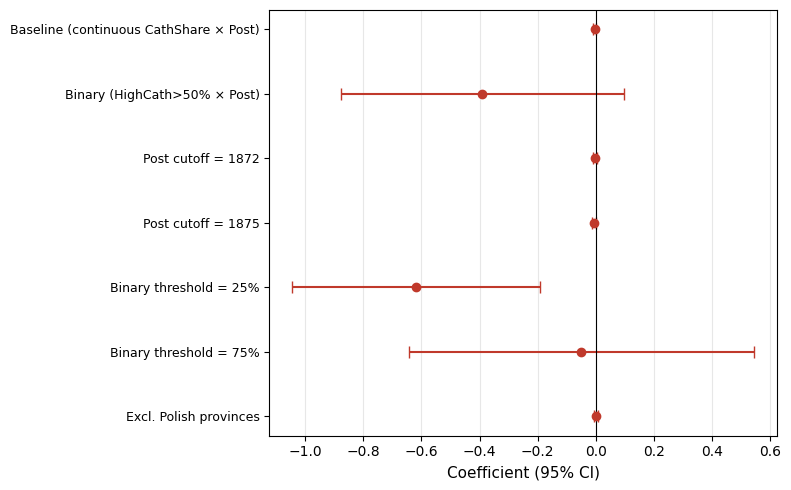

In [14]:
rob = run_robustness(panel, outcome="cbr")
print(rob.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Save figure
fig, ax = plot_robustness_table(rob, savepath=str(OUTPUTS / "fig6_robustness.png"))
plt.show()

**Interpretation.** None of the alternative specifications produce a significant CBR effect. The post cutoff and the threshold definitions don't matter — the result simply isn't there for crude birth rate under TWFE. Excluding the Polish provinces reverses the small remaining negative point estimate to a small positive one, foreshadowing the heterogeneity finding in notebook 03 (the Catholic effect is concentrated in Polish provinces).

## 13. What's next

- **Notebook 03** explores *mechanisms* (channels, heterogeneity) and *falsifications* (Jewish-share placebo, fake-treatment placebo, triple-difference Polish), which together explain why the Catholic effect is essentially Polish.
- **Notebook 04** brings the IV strategy (Wittenberg, bishop's-seat distance, multi-instrument 2SLS with Wooldridge over-id), Conley spatial HAC standard errors, the wild cluster bootstrap on small sub-samples, and the IV-implied counterfactual fertility paths.